Neste trabalho, foram construídos dois modelos de redes neurais convolucionais para classificar imagens territoriais do dataset Intel Image Classification. As classes utilizadas foram buildings, forest, glacier, mountain, sea e street.

O primeiro modelo foi uma CNN simples, sem técnicas explícitas de regularização. Esse modelo conseguiu aprender padrões visuais das imagens, como formas, cores e texturas, mas pode apresentar maior risco de overfitting.

O segundo modelo utilizou Batch Normalization e Dropout. O Batch Normalization ajuda a tornar o treinamento mais estável, enquanto o Dropout reduz o risco de overfitting. Por isso, esse modelo tende a generalizar melhor para imagens novas.

Ao comparar os dois modelos, é possível observar qual deles obteve melhor acurácia nos dados de teste. Para o contexto de monitoramento territorial, o modelo regularizado é mais indicado, pois apresenta uma estrutura mais robusta para classificar imagens de ambientes urbanos e naturais.

In [14]:
# =========================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import os
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# =========================================
# 2. INSTALAÇÃO DO DATASET
# =========================================

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Dataset baixado em:")
print(path)

print("Pastas encontradas:")
print(os.listdir(path))

Dataset baixado em:
C:\Users\Administrator\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2
Pastas encontradas:
['seg_pred', 'seg_test', 'seg_train']


In [ ]:
# =========================================
# 3. DEFINIÇÃO DOS DIRETÓRIOS DE TREINO E TESTE
# =========================================

train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

print("Pasta de treino:", train_dir)
print("Pasta de teste:", test_dir)

print("Classes de treino:")
print(os.listdir(train_dir))

Pasta de treino: C:\Users\Administrator\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
Pasta de teste: C:\Users\Administrator\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test
Classes de treino:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# =========================================
# 4. CARREGAR E PREPROCESSAR AS IMAGENS
# =========================================

img_size = (150, 150)
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [ ]:
# =========================================
# 5. EXPLORAR AS CLASSES DO DATASET
# =========================================

classes = train_data.class_names

print("Classes encontradas:")
print(classes)

Classes encontradas:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# =========================================
# 6. NORMALIZAR OS DADOS
# =========================================

normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
# =========================================
# 7. CNN SIMPLES
# =========================================

model_simple = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

c:\Users\Administrator\Documents\PUC Minas\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# =========================================
# 8. COMPILAÇÃO DA CNN
# =========================================

model_simple.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# =========================================
# 9. TREINAMENTO DA CNN
# =========================================

history_simple = model_simple.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 381s 857ms/step - accuracy: 0.6284 - loss: 0.9714 - val_accuracy: 0.7170 - val_loss: 0.7780
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 367s 825ms/step - accuracy: 0.7711 - loss: 0.6233 - val_accuracy: 0.7980 - val_loss: 0.5752
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 409s 932ms/step - accuracy: 0.8271 - loss: 0.4826 - val_accuracy: 0.8023 - val_loss: 0.5608
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.8748 - loss: 0.3583 - val_accuracy: 0.8130 - val_loss: 0.5793
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 461s 1s/step - accuracy: 0.9101 - loss: 0.2523 - val_accuracy: 0.7987 - val_loss: 0.6659
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 340s 775ms/step - accuracy: 0.9382 - loss: 0.1811 - val_accuracy: 0.8057 - val_loss: 0.7637
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 376s 762ms/step - accuracy: 0.9623 - loss: 0.1176 - val_accuracy: 0.8023 - val_loss: 0.7803
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 340s 775ms/step - accuracy: 0.9723 - loss:

In [15]:
# =========================================
# 10. AVALIAÇÃO DA CNN
# =========================================

loss_simple, acc_simple = model_simple.evaluate(test_data)

print("Acurácia da CNN simples:", acc_simple)

94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.7990 - loss: 1.0136
Acurácia da CNN simples: 0.7990000247955322


In [16]:
# =========================================
# 12. CRIAÇÃO DA CNN COM BATCH NORMALIZATION E DROPOUT
# =========================================

model_regularized = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

In [17]:
# =========================================
# 13. COMPILAÇÃO DA CNN REGULARIZADA
# =========================================

model_regularized.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# =========================================
# 14. TREINAMENTO DA CNN REGULARIZADA
# =========================================

history_regularized = model_regularized.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 732s 2s/step - accuracy: 0.6536 - loss: 0.9705 - val_accuracy: 0.4110 - val_loss: 3.1528
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 714s 2s/step - accuracy: 0.7695 - loss: 0.6431 - val_accuracy: 0.7077 - val_loss: 0.7726
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 737s 2s/step - accuracy: 0.8122 - loss: 0.5233 - val_accuracy: 0.8050 - val_loss: 0.5365
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 758s 2s/step - accuracy: 0.8403 - loss: 0.4462 - val_accuracy: 0.7187 - val_loss: 0.8429
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - accuracy: 0.8614 - loss: 0.3871 - val_accuracy: 0.7147 - val_loss: 0.8361
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 747s 2s/step - accuracy: 0.8747 - loss: 0.3510 - val_accuracy: 0.7243 - val_loss: 0.9014
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 755s 2s/step - accuracy: 0.8968 - loss: 0.2927 - val_accuracy: 0.7843 - val_loss: 0.6494
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 774s 2s/step - accuracy: 0.9052 - loss: 0.2674 - val_accu

In [19]:
# =========================================
# 15. AVALIAÇÃO DA CNN REGULARIZADA
# =========================================

loss_reg, acc_reg = model_regularized.evaluate(test_data)

print("Acurácia da CNN regularizada:", acc_reg)

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 238ms/step - accuracy: 0.8423 - loss: 0.4902
Acurácia da CNN regularizada: 0.8423333168029785


In [20]:
# =========================================
# 16. COMPARAÇÃO DOS MODELOS
# =========================================

print("Comparação dos modelos")
print("----------------------")
print("CNN simples:", acc_simple)
print("CNN regularizada:", acc_reg)

Comparação dos modelos
----------------------
CNN simples: 0.7990000247955322
CNN regularizada: 0.8423333168029785


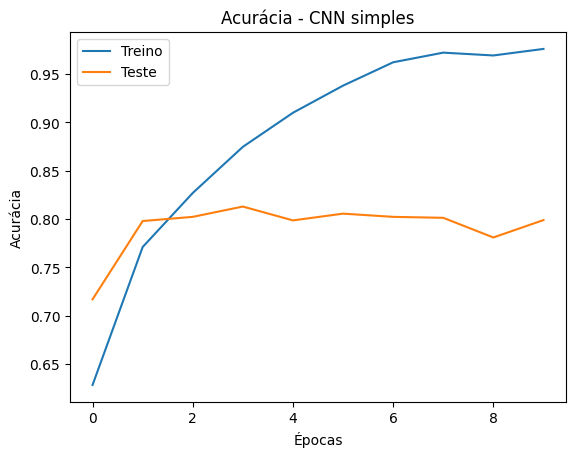

In [21]:
# =========================================
# 17. GRÁFICO DA CNN SIMPLES
# =========================================

plt.plot(history_simple.history['accuracy'], label='Treino')
plt.plot(history_simple.history['val_accuracy'], label='Teste')
plt.title('Acurácia - CNN simples')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

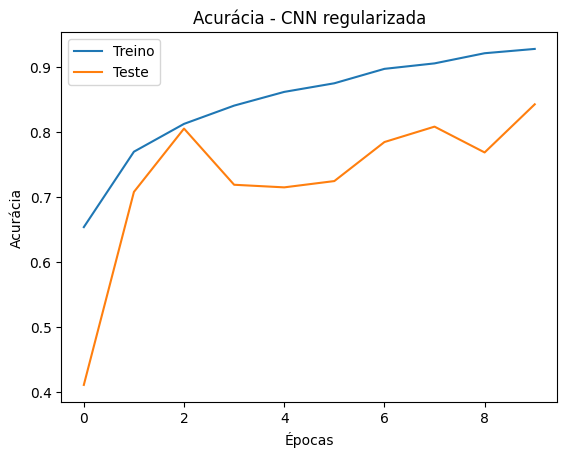

In [22]:
# =========================================
# 18. GRÁFICO DA CNN REGULARIZADA
# =========================================

plt.plot(history_regularized.history['accuracy'], label='Treino')
plt.plot(history_regularized.history['val_accuracy'], label='Teste')
plt.title('Acurácia - CNN regularizada')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()